# ECOS — Block 1: Static Characterization (per cycle)

**Objective:** Characterize the effect of PVA% and PG% on $C_l$ and density at a fixed
freeze-thaw cycle. Cross-sectional analysis; temporal evolution is Block 2.

**Hypotheses tested:** H1 (PVA→$C_l$), H2 (PG→$C_l$), H4 (PVA→density) — *Study Rules §1*.

**Reproducibility thresholds:** CV < 1% for $C_l$; SD < 0.03 g/cm³ for density.

> Before interpreting any result, complete the checklist in *Study Rules §8*.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import stats
from IPython.display import display

sys.path.insert(0, str(Path().resolve()))
import ecos_loader

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

base_dir = Path('../database')
df = ecos_loader.build_catalog(base_dir)

for col in ('pva_pct', 'pg_pct', 'cycle'):
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['pva_real'] = df['pva_pct'].apply(lambda x: x / 10 if x > 100 else x)

fig_dir = Path('figures')
fig_dir.mkdir(exist_ok=True)

# Color convention (Study Rules §7): tab10 — PVA 10%=blue, 12.5%=orange, 15%=green
_cmap      = plt.cm.tab10
PVA_LEVELS = sorted(df['pva_real'].dropna().unique())
PG_LEVELS  = sorted(df['pg_pct'].dropna().unique())
PVA_COLOR  = {pva: _cmap(i) for i, pva in enumerate(PVA_LEVELS)}
PG_COLOR   = {pg:  _cmap(i) for i, pg  in enumerate(PG_LEVELS)}
PG_MARKER  = {pg: m for pg, m in zip(PG_LEVELS, ['o', 's', '^', 'D'])}

cycles_avail = sorted(df['cycle'].dropna().unique())
print(f'Catalog shape: {df.shape}')
print(f'Cycles available: {cycles_avail}')
print(f'PVA levels (real): {PVA_LEVELS}')
print(f'PG levels: {PG_LEVELS}')


[scan_database] loaded 180 US, 180 DENS
Catalog shape: (180, 26)
Cycles available: [np.int64(3), np.int64(4), np.int64(5)]
PVA levels (real): [np.float64(10.0), np.float64(12.5), np.float64(15.0)]
PG levels: [np.int64(0), np.int64(5), np.int64(10), np.int64(15)]


---
## Block 1 — Cycle selector

Change `CYCLE` to the desired freeze-thaw cycle number and **re-run all cells below**
to repeat the entire analysis for that cycle independently.

In [27]:
# ========== USER: select cycle to analyze ==========
CYCLE = 5
df_cycle = df[df['cycle'] == CYCLE].copy()
print(f'Block 1: analyzing cycle {CYCLE}')
print(f'  Specimens : {len(df_cycle)}')
n_cond = df_cycle[['pva_real', 'pg_pct']].drop_duplicates().shape[0]
print(f'  Conditions: {n_cond}')


Block 1: analyzing cycle 5
  Specimens : 60
  Conditions: 12


---
## Cell 1.1 — Summary statistics table

One row per condition (PVA% × PG%). Reports mean ± SD, n, and CV% for $C_l$, density,
thickness, impedance Z, and modulus M.

**CV = SD/mean × 100%** is more informative than SD alone when comparing quantities
with different scales. CV < 1% for $C_l$ is excellent; > 5% warrants investigation.

**Red flags:** n < 5 (missing data), SD($C_l$) > 15 m/s, density < 1.0 g/cm³.

In [28]:
# --- Cell 1.1: Summary statistics table ---
metrics_cfg = [
    ('US_Cl',             'Cl (m/s)',   2),
    ('DENS_density_gcm3', 'rho (g/cm3)', 4),
    ('US_d',              'd (m)',       6),
    ('Z',                 'Z (Rayl)',    0),
    ('M_GPa',             'M (GPa)',     4),
]
avail_metrics = [(c, lbl, dp) for c, lbl, dp in metrics_cfg if c in df_cycle.columns]

rows = []
for (pva, pg), grp in df_cycle.groupby(['pva_real', 'pg_pct']):
    row = {'PVA (%)': pva, 'PG (%)': int(pg)}
    for col, lbl, dp in avail_metrics:
        vals = grp[col].dropna()
        n = len(vals)
        m = vals.mean() if n else np.nan
        s = vals.std(ddof=1) if n > 1 else np.nan
        cv = (s / m * 100) if (n > 1 and not np.isnan(m) and m != 0) else np.nan
        fmt = '{:.' + str(dp) + 'f}'
        if n > 0 and not np.isnan(m):
            row[lbl + ' mean+/-SD'] = fmt.format(m) + ' +/- ' + fmt.format(s) if not np.isnan(s) else fmt.format(m)
            row[lbl + ' CV%'] = f'{cv:.2f}' if not np.isnan(cv) else '-'
        else:
            row[lbl + ' mean+/-SD'] = '-'
            row[lbl + ' CV%'] = '-'
    row['n'] = int(grp['US_Cl'].notna().sum())
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index(['PVA (%)', 'PG (%)'])
print(f'Summary statistics — Cycle {CYCLE}\n')
display(summary_df)

# Red flags (Study Rules §5)
print('\nRed flags:')
found = False
for (pva, pg), grp in df_cycle.groupby(['pva_real', 'pg_pct']):
    n = int(grp['US_Cl'].notna().sum())
    if n < 5:
        print(f'  [!] PVA {pva}% PG {int(pg)}%: n={n} < 5 (missing data)')
        found = True
    if 'US_Cl' in grp.columns:
        s_cl = grp['US_Cl'].std()
        if pd.notna(s_cl) and s_cl > 15:
            print(f'  [!] PVA {pva}% PG {int(pg)}%: SD(Cl)={s_cl:.1f} m/s > 15')
            found = True
    if 'DENS_density_gcm3' in grp.columns:
        nb = int((grp['DENS_density_gcm3'] < 1.0).sum())
        if nb:
            print(f'  [!] PVA {pva}% PG {int(pg)}%: {nb} density value(s) < 1.0 g/cm3')
            found = True
if not found:
    print('  None detected.')


Summary statistics — Cycle 5



Cl (m/s) mean+/-SD Cl (m/s) CV% rho (g/cm3) mean+/-SD  \
PVA (%) PG (%)                                                         
10.0    0        1615.65 +/- 4.01         0.25     0.9929 +/- 0.0172   
        5        1598.26 +/- 4.79         0.30     0.9900 +/- 0.0220   
        10      1600.98 +/- 18.67         1.17     1.0029 +/- 0.0538   
        15      1578.47 +/- 17.88         1.13     0.9966 +/- 0.0368   
12.5    0        1604.62 +/- 3.39         0.21     0.9847 +/- 0.0146   
        5        1601.34 +/- 4.19         0.26     0.9781 +/- 0.0077   
        10       1611.09 +/- 3.72         0.23     0.9964 +/- 0.0401   
        15       1605.20 +/- 3.31         0.21     1.0217 +/- 0.0180   
15.0    0        1610.36 +/- 3.74         0.23     1.0139 +/- 0.0186   
        5        1608.79 +/- 2.10         0.13     0.9966 +/- 0.0119   
        10       1603.44 +/- 3.06         0.19     1.0170 +/- 0.0432   
        15       1604.84 +/- 2.93         0.18     1.0017 +/- 0.0262   

               rho (g/cm3) CV%        d (m) mean+/-SD d (m) CV%  \
PVA (%) PG (%)                                                    
10.0    0                 1.73  0.003329 +/- 0.000122      3.67   
        5                 2.22  0.003247 +/- 0.000188      5.80   
        10                5.36  0.003361 +/- 0.000162      4.82   
        15                3.69  0.003396 +/- 0.000085      2.51   
12.5    0                 1.48  0.003148 +/- 0.000060      1.92   
        5                 0.79  0.003353 +/- 0.000074      2.22   
        10                4.03  0.003465 +/- 0.000109      3.14   
        15                1.76  0.003286 +/- 0.000156      4.76   
15.0    0                 1.84  0.003275 +/- 0.000127      3.87   
        5                 1.20  0.003324 +/- 0.000028      0.84   
        10                4.25  0.003328 +/- 0.000138      4.16   
        15                2.61  0.003497 +/- 0.000140      4.00   

               Z (Rayl) mean+/-SD Z (Rayl) CV%  M (GPa) mean+/-SD M (GPa) CV%  \
PVA (%) PG (%)                                                                  
10.0    0       1604133 +/- 29154         1.82  2.5918 +/- 0.0500        1.93   
        5       1582186 +/- 32045         2.03  2.5287 +/- 0.0469        1.86   
        10      1605846 +/- 94323         5.87  2.5717 +/- 0.1690        6.57   
        15      1573026 +/- 60428         3.84  2.4832 +/- 0.1063        4.28   
12.5    0       1580114 +/- 21743         1.38  2.5355 +/- 0.0328        1.30   
        5        1566246 +/- 9253         0.59  2.5081 +/- 0.0117        0.47   
        10      1605355 +/- 65879         4.10  2.5864 +/- 0.1084        4.19   
        15      1640041 +/- 31967         1.95  2.6327 +/- 0.0564        2.14   
15.0    0       1632754 +/- 32752         2.01  2.6294 +/- 0.0575        2.19   
        5       1603247 +/- 18593         1.16  2.5793 +/- 0.0293        1.14   
        10      1630740 +/- 68576         4.21  2.6148 +/- 0.1090        4.17   
        15      1607450 +/- 39408         2.45  2.5796 +/- 0.0592        2.29   

                n  
PVA (%) PG (%)     
10.0    0       5  
        5       5  
        10      5  
        15      5  
12.5    0       5  
        5       5  
        10      5  
        15      5  
15.0    0       5  
        5       5  
        10      5  
        15      5


Red flags:
  [!] PVA 10.0% PG 0%: 3 density value(s) < 1.0 g/cm3
  [!] PVA 10.0% PG 5%: 4 density value(s) < 1.0 g/cm3
  [!] PVA 10.0% PG 10%: SD(Cl)=18.7 m/s > 15
  [!] PVA 10.0% PG 10%: 2 density value(s) < 1.0 g/cm3
  [!] PVA 10.0% PG 15%: SD(Cl)=17.9 m/s > 15
  [!] PVA 10.0% PG 15%: 3 density value(s) < 1.0 g/cm3
  [!] PVA 12.5% PG 0%: 4 density value(s) < 1.0 g/cm3
  [!] PVA 12.5% PG 5%: 5 density value(s) < 1.0 g/cm3
  [!] PVA 12.5% PG 10%: 4 density value(s) < 1.0 g/cm3
  [!] PVA 15.0% PG 0%: 1 density value(s) < 1.0 g/cm3
  [!] PVA 15.0% PG 5%: 3 density value(s) < 1.0 g/cm3
  [!] PVA 15.0% PG 10%: 2 density value(s) < 1.0 g/cm3
  [!] PVA 15.0% PG 15%: 2 density value(s) < 1.0 g/cm3


---
## Cell 1.2 — Grouped boxplots: $C_l$ by condition

With n=5, the individual data points **are** the data. The box is context.
Box = IQR; line = median; whiskers = 1.5×IQR; points outside = potential outliers.
Points are jittered horizontally (fixed seed) so overlapping values remain visible.

**Pedagogical note:** With n=5 the median can be any of the 5 values. Do not
over-interpret the box shape. Look at the scatter of individual points first.

C:\Users\alrom\AppData\Local\Temp\ipykernel_22352\4019791769.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_cl, labels=labels_cond, patch_artist=True,


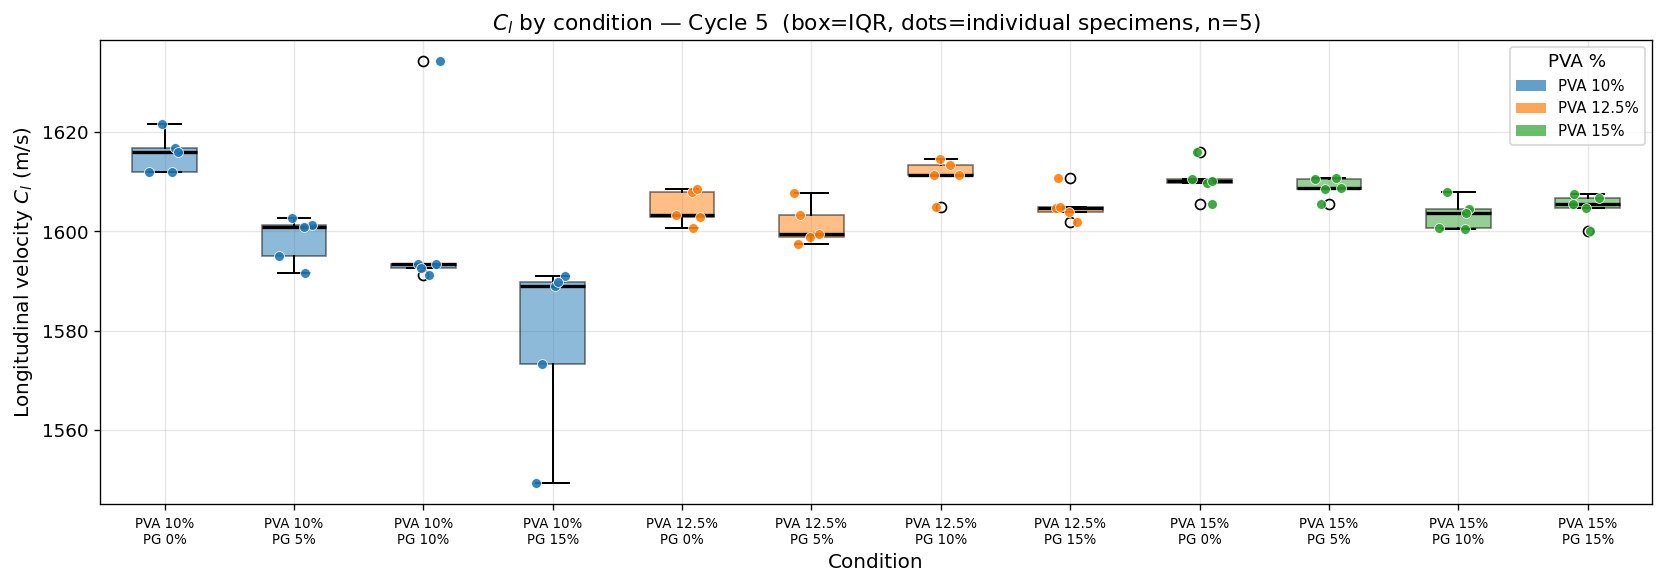

In [29]:
# --- Cell 1.2: Boxplots Cl by condition + jittered individual points ---
rng = np.random.default_rng(42)

conditions = (
    df_cycle[['pva_real', 'pg_pct']]
    .drop_duplicates()
    .sort_values(['pva_real', 'pg_pct'])
    .reset_index(drop=True)
)
labels_cond = [f'PVA {r.pva_real:.4g}%\nPG {int(r.pg_pct)}%' for _, r in conditions.iterrows()]
data_cl = [
    df_cycle[(df_cycle['pva_real'] == r.pva_real) & (df_cycle['pg_pct'] == r.pg_pct)]['US_Cl'].dropna().values
    for _, r in conditions.iterrows()
]
colors_box = [PVA_COLOR[r.pva_real] for _, r in conditions.iterrows()]

fig, ax = plt.subplots(figsize=(14, 5))
bp = ax.boxplot(data_cl, labels=labels_cond, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2},
                whiskerprops={'linewidth': 1.2},
                capprops={'linewidth': 1.2})

for i, (patch, col) in enumerate(zip(bp['boxes'], colors_box)):
    patch.set_facecolor(col)
    patch.set_alpha(0.5)
    x_pts = rng.uniform(-0.15, 0.15, size=len(data_cl[i])) + (i + 1)
    ax.scatter(x_pts, data_cl[i], color=col, s=35, zorder=5,
               edgecolors='white', linewidths=0.5, alpha=0.9)

ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Longitudinal velocity $C_l$ (m/s)', fontsize=12)
ax.set_title(f'$C_l$ by condition — Cycle {CYCLE}  (box=IQR, dots=individual specimens, n=5)', fontsize=13)
ax.tick_params(axis='x', labelsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PVA_COLOR[pva], alpha=0.7, label=f'PVA {pva:.4g}%')
                   for pva in PVA_LEVELS]
ax.legend(handles=legend_elements, title='PVA %', fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(fig_dir / f'B1_02_boxplot_Cl_C{CYCLE}.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Cell 1.3 — Grouped boxplots: density by condition

Same layout as 1.2 but for density. The red dashed line at $\rho = 1.0$ g/cm³ marks
the physical lower bound for PVA hydrogels. Any points below it need investigation
(vessel radius error, air bubbles — see *Study Rules §4*).

C:\Users\alrom\AppData\Local\Temp\ipykernel_22352\4035797760.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_dens, labels=labels_cond, patch_artist=True,


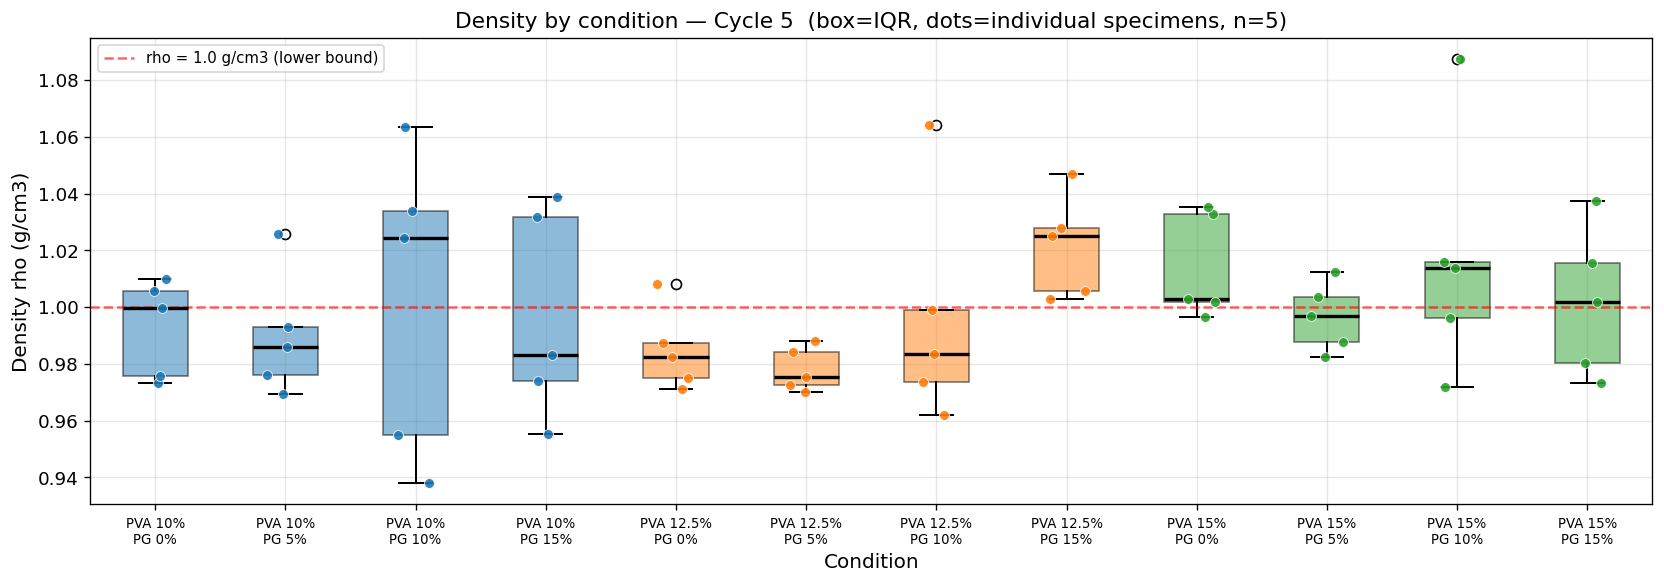

[!] 33 specimen(s) with density < 1.0 g/cm3 — check Study Rules §4:


,pva_real,pg_pct,piece,DENS_density_gcm3
10,10.0,0,A,0.9998
12,10.0,0,C,0.9731
14,10.0,0,E,0.9758
27,10.0,10,C,0.9379
29,10.0,10,E,0.9550
41,10.0,15,B,0.9741
42,10.0,15,C,0.9831
43,10.0,15,D,0.9552
55,10.0,5,A,0.9859
56,10.0,5,B,0.9931


In [30]:
# --- Cell 1.3: Boxplots density by condition + jittered individual points ---
data_dens = [
    df_cycle[(df_cycle['pva_real'] == r.pva_real) & (df_cycle['pg_pct'] == r.pg_pct)]['DENS_density_gcm3'].dropna().values
    for _, r in conditions.iterrows()
]

fig, ax = plt.subplots(figsize=(14, 5))
bp = ax.boxplot(data_dens, labels=labels_cond, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2},
                whiskerprops={'linewidth': 1.2},
                capprops={'linewidth': 1.2})

for i, (patch, col) in enumerate(zip(bp['boxes'], colors_box)):
    patch.set_facecolor(col)
    patch.set_alpha(0.5)
    x_pts = rng.uniform(-0.15, 0.15, size=len(data_dens[i])) + (i + 1)
    ax.scatter(x_pts, data_dens[i], color=col, s=35, zorder=5,
               edgecolors='white', linewidths=0.5, alpha=0.9)

ax.axhline(1.0, color='red', linestyle='--', alpha=0.6, linewidth=1.5,
           label='rho = 1.0 g/cm3 (lower bound)')

ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Density rho (g/cm3)', fontsize=12)
ax.set_title(f'Density by condition — Cycle {CYCLE}  (box=IQR, dots=individual specimens, n=5)', fontsize=13)
ax.tick_params(axis='x', labelsize=8)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(fig_dir / f'B1_03_boxplot_density_C{CYCLE}.png', dpi=150, bbox_inches='tight')
plt.show()

below = df_cycle[df_cycle['DENS_density_gcm3'] < 1.0][['pva_real', 'pg_pct', 'piece', 'DENS_density_gcm3']]
if not below.empty:
    print(f'[!] {len(below)} specimen(s) with density < 1.0 g/cm3 — check Study Rules §4:')
    display(below)
else:
    print('No density values below 1.0 g/cm3.')


---
## Cell 1.4 — Scatter: $C_l$ vs PVA%, colored by PG%

Each point = one specimen. Groups are jittered horizontally to avoid overlap.
Vertical trend within a color group = PVA effect at that PG level.
Separation between colors at the same PVA% = PG effect.

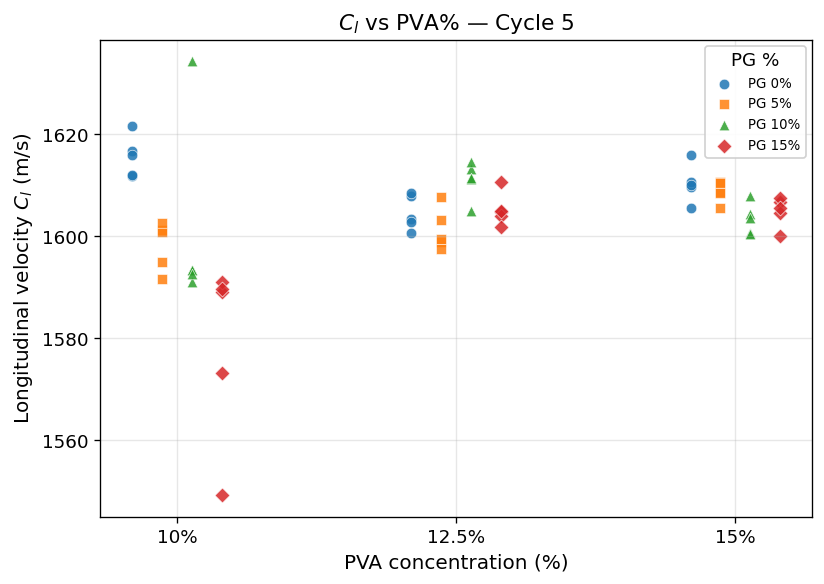

In [31]:
# --- Cell 1.4: Cl vs PVA% — colored by PG%, jittered ---
offsets_pva = {pg: dx for pg, dx in zip(PG_LEVELS, np.linspace(-0.4, 0.4, len(PG_LEVELS)))}

fig, ax = plt.subplots(figsize=(7, 5))
for pg in PG_LEVELS:
    sub = df_cycle[df_cycle['pg_pct'] == pg]
    ax.scatter(sub['pva_real'] + offsets_pva[pg], sub['US_Cl'],
               color=PG_COLOR[pg], marker=PG_MARKER[pg],
               s=40, alpha=0.85, edgecolors='white', linewidths=0.4,
               label=f'PG {int(pg)}%')

ax.set_xticks(PVA_LEVELS)
ax.set_xticklabels([f'{v:.4g}%' for v in PVA_LEVELS], fontsize=11)
ax.set_xlabel('PVA concentration (%)', fontsize=12)
ax.set_ylabel('Longitudinal velocity $C_l$ (m/s)', fontsize=12)
ax.set_title(f'$C_l$ vs PVA% — Cycle {CYCLE}', fontsize=13)
ax.legend(title='PG %', fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / f'B1_04_scatter_Cl_vs_PVA_C{CYCLE}.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Cell 1.5 — Scatter: $C_l$ vs PG%, colored by PVA%

Complementary view to 1.4 with axes swapped. If all PVA colors follow the same trend
with PG, PG is acting as a secondary factor independent of PVA.

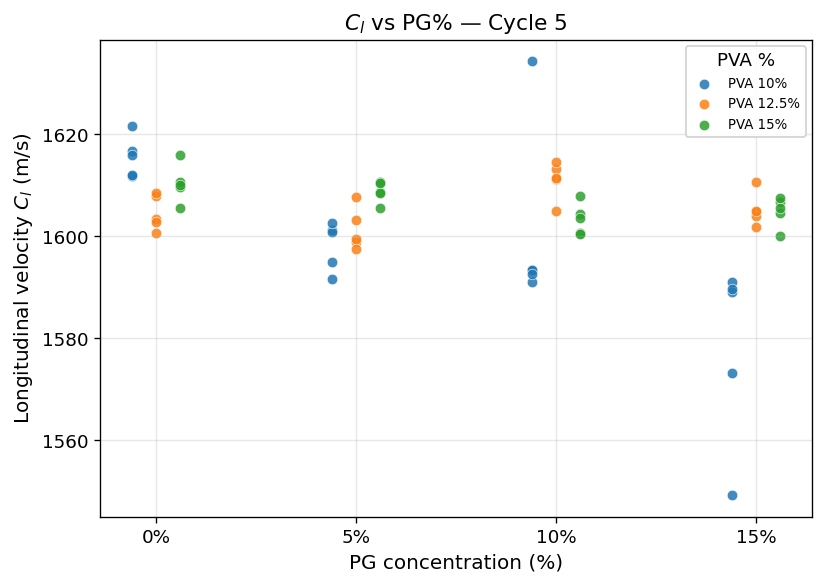

In [32]:
# --- Cell 1.5: Cl vs PG% — colored by PVA%, jittered ---
offsets_pg = {pva: dx for pva, dx in zip(PVA_LEVELS, np.linspace(-0.6, 0.6, len(PVA_LEVELS)))}

fig, ax = plt.subplots(figsize=(7, 5))
for pva in PVA_LEVELS:
    sub = df_cycle[df_cycle['pva_real'] == pva]
    ax.scatter(sub['pg_pct'] + offsets_pg[pva], sub['US_Cl'],
               color=PVA_COLOR[pva], s=40, alpha=0.85,
               edgecolors='white', linewidths=0.4,
               label=f'PVA {pva:.4g}%')

ax.set_xticks(PG_LEVELS)
ax.set_xticklabels([f'{int(v)}%' for v in PG_LEVELS], fontsize=11)
ax.set_xlabel('PG concentration (%)', fontsize=12)
ax.set_ylabel('Longitudinal velocity $C_l$ (m/s)', fontsize=12)
ax.set_title(f'$C_l$ vs PG% — Cycle {CYCLE}', fontsize=13)
ax.legend(title='PVA %', fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / f'B1_05_scatter_Cl_vs_PG_C{CYCLE}.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Cell 1.6 — 3D scatter + 2D contour: $C_l$ = f(PVA%, PG%)

Left: 3D scatter with fitted planar surface. Adjust `ELEV`/`AZIM` to rotate the view.
Right: 2D contour (paper-friendly; carries the same information as the 3D plot).

**Pedagogical note:** 3D plots are seductive but often misleading in print. The 2D contour
is the preferred figure for publication. Show both to students and compare readability.

Surface twist = interaction effect (PVA effect changes with PG level).

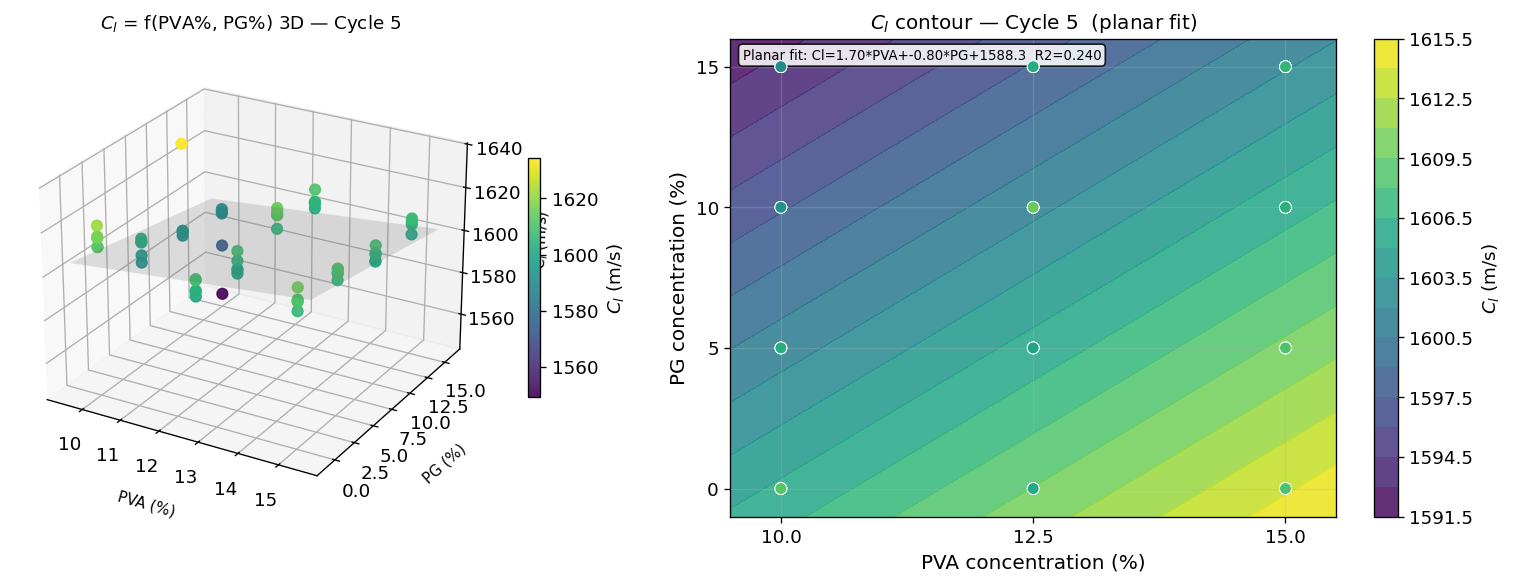

Planar fit: Cl=1.70*PVA+-0.80*PG+1588.3  R2=0.240


In [33]:
# --- Cell 1.6: 3D scatter + planar fit + 2D contour ---
ELEV, AZIM = 25, -60  # adjust to rotate the 3D view

mask6 = df_cycle[['pva_real', 'pg_pct', 'US_Cl']].notna().all(axis=1)
sub6  = df_cycle[mask6]
pva_a = sub6['pva_real'].values
pg_a  = sub6['pg_pct'].values
cl_a  = sub6['US_Cl'].values

# Planar fit: Cl = a*PVA + b*PG + c
X_fit = np.column_stack([pva_a, pg_a, np.ones(len(pva_a))])
(a_f, b_f, c_f), _, _, _ = np.linalg.lstsq(X_fit, cl_a, rcond=None)
cl_pred = a_f * pva_a + b_f * pg_a + c_f
SS_res = np.sum((cl_a - cl_pred) ** 2)
SS_tot = np.sum((cl_a - cl_a.mean()) ** 2)
R2_fit = 1 - SS_res / SS_tot

# Grid for surface
pva_g = np.linspace(min(PVA_LEVELS) - 0.5, max(PVA_LEVELS) + 0.5, 30)
pg_g  = np.linspace(min(PG_LEVELS) - 1, max(PG_LEVELS) + 1, 30)
PVA_G, PG_G = np.meshgrid(pva_g, pg_g)
CL_G = a_f * PVA_G + b_f * PG_G + c_f

fig = plt.figure(figsize=(14, 5))

# --- Left: 3D ---
ax3 = fig.add_subplot(121, projection='3d')
sc3 = ax3.scatter(pva_a, pg_a, cl_a, c=cl_a, cmap='viridis', s=40, alpha=0.9, zorder=5)
ax3.plot_surface(PVA_G, PG_G, CL_G, alpha=0.2, color='grey')
ax3.set_xlabel('PVA (%)', fontsize=9, labelpad=8)
ax3.set_ylabel('PG (%)', fontsize=9, labelpad=8)
ax3.set_zlabel('$C_l$ (m/s)', fontsize=9, labelpad=8)
ax3.set_title(f'$C_l$ = f(PVA%, PG%) 3D — Cycle {CYCLE}', fontsize=11)
ax3.view_init(elev=ELEV, azim=AZIM)
plt.colorbar(sc3, ax=ax3, shrink=0.5, label='$C_l$ (m/s)')

# --- Right: 2D contour ---
ax2 = fig.add_subplot(122)
cf = ax2.contourf(PVA_G, PG_G, CL_G, levels=20, cmap='viridis', alpha=0.85)
plt.colorbar(cf, ax=ax2, label='$C_l$ (m/s)')
ax2.scatter(pva_a, pg_a, c=cl_a, cmap='viridis', s=50, edgecolors='white', linewidths=0.5, zorder=5)
ax2.set_xticks(PVA_LEVELS)
ax2.set_yticks(PG_LEVELS)
ax2.set_xlabel('PVA concentration (%)', fontsize=12)
ax2.set_ylabel('PG concentration (%)', fontsize=12)
fit_str = f'Planar fit: Cl={a_f:.2f}*PVA+{b_f:.2f}*PG+{c_f:.1f}  R2={R2_fit:.3f}'
ax2.set_title(f'$C_l$ contour — Cycle {CYCLE}  (planar fit)', fontsize=12)
ax2.text(0.02, 0.98, fit_str, transform=ax2.transAxes, fontsize=8, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / f'B1_06_3D_Cl_C{CYCLE}.png', dpi=150, bbox_inches='tight')
plt.show()
print(fit_str)


---
## Cell 1.7 — Heatmap: mean $C_l$ by (PVA%, PG%)

Most compact representation of the full 3×4 factorial design.
Color gradient along rows = PVA effect; along columns = PG effect; diagonal = interaction.
Each cell annotated with mean ± SD. Likely to be a key figure in the paper.

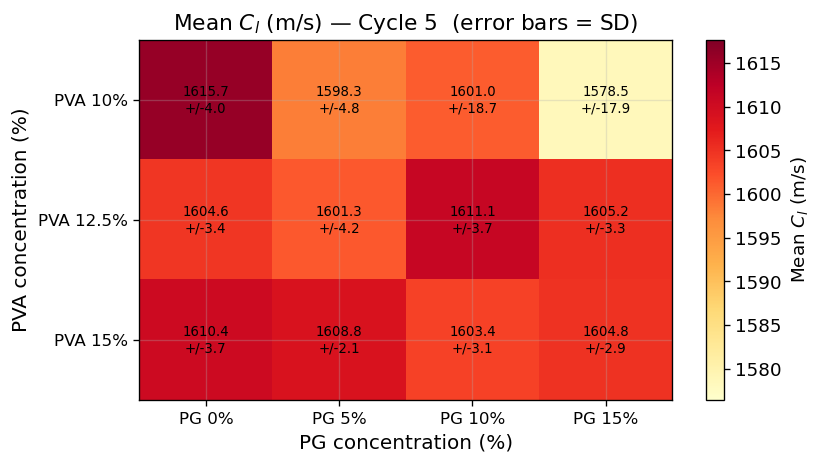

In [34]:
# --- Cell 1.7: Heatmap — mean Cl by (PVA%, PG%) ---
grp_cl7 = df_cycle.groupby(['pva_real', 'pg_pct'])['US_Cl'].agg(['mean', 'std']).reset_index()

pva_idx = sorted(grp_cl7['pva_real'].unique())
pg_idx  = sorted(grp_cl7['pg_pct'].unique())
cl_mat  = np.full((len(pva_idx), len(pg_idx)), np.nan)
sd_cl   = np.full((len(pva_idx), len(pg_idx)), np.nan)

for _, row in grp_cl7.iterrows():
    i = pva_idx.index(row['pva_real'])
    j = pg_idx.index(row['pg_pct'])
    cl_mat[i, j] = row['mean']
    sd_cl[i, j]  = row['std']

fig, ax = plt.subplots(figsize=(7, 4))
vmin7, vmax7 = np.nanmin(cl_mat) - 2, np.nanmax(cl_mat) + 2
im = ax.imshow(cl_mat, aspect='auto', cmap='YlOrRd', vmin=vmin7, vmax=vmax7)
plt.colorbar(im, ax=ax, label='Mean $C_l$ (m/s)')

ax.set_xticks(range(len(pg_idx)))
ax.set_yticks(range(len(pva_idx)))
ax.set_xticklabels([f'PG {int(v)}%' for v in pg_idx], fontsize=10)
ax.set_yticklabels([f'PVA {v:.4g}%' for v in pva_idx], fontsize=10)
ax.set_xlabel('PG concentration (%)', fontsize=12)
ax.set_ylabel('PVA concentration (%)', fontsize=12)
ax.set_title(f'Mean $C_l$ (m/s) — Cycle {CYCLE}  (error bars = SD)', fontsize=13)

for i in range(len(pva_idx)):
    for j in range(len(pg_idx)):
        if not np.isnan(cl_mat[i, j]):
            txt = f'{cl_mat[i,j]:.1f}\n+/-{sd_cl[i,j]:.1f}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(fig_dir / f'B1_07_heatmap_Cl_C{CYCLE}.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Cell 1.8 — Heatmap: mean density by (PVA%, PG%)

Same layout as 1.7 but for density. Used to test H4 visually before the ANOVA.

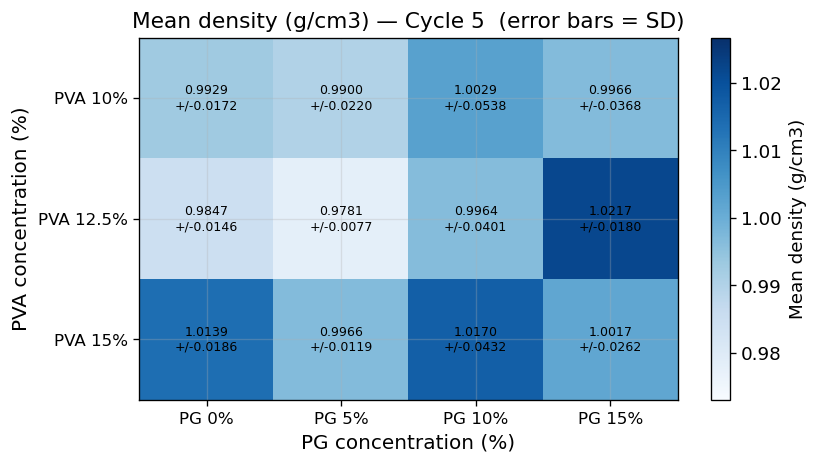

In [35]:
# --- Cell 1.8: Heatmap — mean density by (PVA%, PG%) ---
grp_d8 = df_cycle.groupby(['pva_real', 'pg_pct'])['DENS_density_gcm3'].agg(['mean', 'std']).reset_index()

dens_mat = np.full((len(pva_idx), len(pg_idx)), np.nan)
sd_dens  = np.full((len(pva_idx), len(pg_idx)), np.nan)

for _, row in grp_d8.iterrows():
    i = pva_idx.index(row['pva_real'])
    j = pg_idx.index(row['pg_pct'])
    dens_mat[i, j] = row['mean']
    sd_dens[i, j]  = row['std']

fig, ax = plt.subplots(figsize=(7, 4))
vmin8, vmax8 = np.nanmin(dens_mat) - 0.005, np.nanmax(dens_mat) + 0.005
im = ax.imshow(dens_mat, aspect='auto', cmap='Blues', vmin=vmin8, vmax=vmax8)
plt.colorbar(im, ax=ax, label='Mean density (g/cm3)')

ax.set_xticks(range(len(pg_idx)))
ax.set_yticks(range(len(pva_idx)))
ax.set_xticklabels([f'PG {int(v)}%' for v in pg_idx], fontsize=10)
ax.set_yticklabels([f'PVA {v:.4g}%' for v in pva_idx], fontsize=10)
ax.set_xlabel('PG concentration (%)', fontsize=12)
ax.set_ylabel('PVA concentration (%)', fontsize=12)
ax.set_title(f'Mean density (g/cm3) — Cycle {CYCLE}  (error bars = SD)', fontsize=13)

for i in range(len(pva_idx)):
    for j in range(len(pg_idx)):
        if not np.isnan(dens_mat[i, j]):
            txt = f'{dens_mat[i,j]:.4f}\n+/-{sd_dens[i,j]:.4f}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=7.5)

plt.tight_layout()
plt.savefig(fig_dir / f'B1_08_heatmap_density_C{CYCLE}.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Cell 1.9 — Scatter: $C_l$ vs density (all conditions)

Color = PVA%, marker shape = PG%. Pearson r quantifies $C_l$-$\rho$ coupling.

**Key question:** Can we tune $C_l$ and $\rho$ independently?
- Strong positive correlation → they are coupled; a third degree of freedom needed for tissue matching.
- Weak/no correlation → good news for independent control.

Shaded rectangles = tissue reference regions (Zell 2007, Duck 1990). A phantom condition
that overlaps with a region matches that tissue acoustically **and** mechanically.

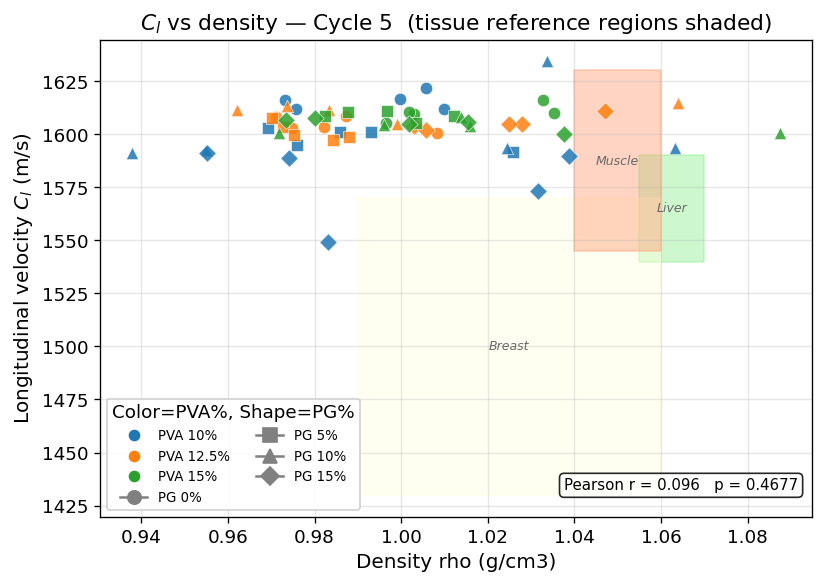

Pearson r = 0.096   p = 0.4677
  Weak coupling: relatively independent control of Cl and rho is possible.


In [36]:
# --- Cell 1.9: Cl vs density — all specimens, tissue reference regions ---
mask9 = df_cycle[['US_Cl', 'DENS_density_gcm3']].notna().all(axis=1)
sub9  = df_cycle[mask9]

r_val, p_val = stats.pearsonr(sub9['DENS_density_gcm3'], sub9['US_Cl'])

fig, ax = plt.subplots(figsize=(7, 5))

# Tissue reference regions (Zell 2007, Duck 1990)
tissue_refs = {
    'Liver': {'dens': (1.055, 1.070), 'cl': (1540, 1590), 'color': 'lightgreen'},
    'Breast': {'dens': (0.990, 1.060), 'cl': (1430, 1570), 'color': 'lightyellow'},
    'Muscle': {'dens': (1.040, 1.060), 'cl': (1545, 1630), 'color': 'lightsalmon'},
}
for name, ref in tissue_refs.items():
    d0, d1 = ref['dens']
    c0, c1 = ref['cl']
    ax.fill_between([d0, d1], c0, c1, color=ref['color'], alpha=0.45, zorder=1)
    ax.text((d0 + d1) / 2, (c0 + c1) / 2, name,
            ha='center', va='center', fontsize=7.5, color='dimgrey', style='italic')

# Data points
for pva in PVA_LEVELS:
    for pg in PG_LEVELS:
        pts = sub9[(sub9['pva_real'] == pva) & (sub9['pg_pct'] == pg)]
        if pts.empty:
            continue
        ax.scatter(pts['DENS_density_gcm3'], pts['US_Cl'],
                   color=PVA_COLOR[pva], marker=PG_MARKER[pg],
                   s=55, alpha=0.85, edgecolors='white', linewidths=0.4, zorder=3)

# Legend
from matplotlib.lines import Line2D
pva_hdl = [Line2D([0], [0], marker='o', color='w', markerfacecolor=PVA_COLOR[pva],
                   markersize=8, label=f'PVA {pva:.4g}%') for pva in PVA_LEVELS]
pg_hdl  = [Line2D([0], [0], marker=PG_MARKER[pg], color='grey',
                   markersize=8, label=f'PG {int(pg)}%') for pg in PG_LEVELS]
ax.legend(handles=pva_hdl + pg_hdl, fontsize=8, framealpha=0.9,
          title='Color=PVA%, Shape=PG%', ncol=2)

corr_str = f'Pearson r = {r_val:.3f}   p = {p_val:.4f}'
ax.text(0.98, 0.05, corr_str, transform=ax.transAxes, fontsize=9,
        ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

ax.set_xlabel('Density rho (g/cm3)', fontsize=12)
ax.set_ylabel('Longitudinal velocity $C_l$ (m/s)', fontsize=12)
ax.set_title(f'$C_l$ vs density — Cycle {CYCLE}  (tissue reference regions shaded)', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / f'B1_09_scatter_Cl_vs_density_C{CYCLE}.png', dpi=150, bbox_inches='tight')
plt.show()

print(corr_str)
if abs(r_val) > 0.7:
    print('  Strong coupling: Cl and rho cannot be tuned independently with this formulation.')
elif abs(r_val) > 0.4:
    print('  Moderate coupling detected.')
else:
    print('  Weak coupling: relatively independent control of Cl and rho is possible.')


---
## Cell 1.10 — Two-way ANOVA: $C_l$ = f(PVA%, PG%)

Tests H1 and H2 (*Study Rules §1*). Reports F, p-value, and $\eta^2$ for:
- Main effect of PVA% on $C_l$
- Main effect of PG% on $C_l$  
- Interaction PVA% × PG%

**Interpretation guide:** Significant (p < 0.05) + large $\eta^2$ (> 0.14) = practically
relevant. Non-significant with n=5 means *inconclusive*, not *no effect* (low power).

**Assumption checks run:** Shapiro-Wilk (normality) + Levene (homogeneity of variance).
**Non-parametric check:** Kruskal-Wallis also computed — if KW and ANOVA disagree, report KW.

`statsmodels` required for full two-way ANOVA; falls back to Kruskal-Wallis if absent.

In [37]:
# --- Cell 1.10: Two-way ANOVA — Cl = f(PVA%, PG%) ---
mask10 = df_cycle[['US_Cl', 'pva_real', 'pg_pct']].notna().all(axis=1)
df_a10 = df_cycle[mask10].copy()
df_a10['pva_cat'] = df_a10['pva_real'].astype(str)
df_a10['pg_cat']  = df_a10['pg_pct'].astype(str)

print(f'Two-way ANOVA: Cl = f(PVA%, PG%) — Cycle {CYCLE}  (n={len(df_a10)})')
print('=' * 60)

# --- Assumption checks ---
print('\n[Assumptions]')
print('Shapiro-Wilk normality (per PVA group):')
for pva, grp in df_a10.groupby('pva_cat'):
    v = grp['US_Cl'].dropna()
    if len(v) >= 3:
        W, p_sw = stats.shapiro(v)
        flag = '' if p_sw > 0.05 else ' [!]'
        print(f'  PVA {pva}%: W={W:.3f}, p={p_sw:.4f}{flag}')

lev_groups = [g['US_Cl'].dropna().values for _, g in df_a10.groupby('pva_cat')]
W_lev, p_lev = stats.levene(*lev_groups)
flag_lev = '' if p_lev > 0.05 else ' [!] heterogeneous variances'
print(f'Levene (homogeneity of variance): W={W_lev:.3f}, p={p_lev:.4f}{flag_lev}')

# --- Helper for eta2 interpretation (also used in Cell 1.11) ---
def interpret_anova(p, eta2, source):
    if source == 'Residual':
        return ''
    sig = 'significant' if p < 0.05 else 'n.s.'
    if eta2 > 0.14:
        eff = 'large eta2'
    elif eta2 > 0.06:
        eff = 'medium eta2'
    else:
        eff = 'small eta2'
    return f'{sig}, {eff}'

# --- Two-way ANOVA (statsmodels) ---
try:
    import statsmodels.formula.api as smf
    from statsmodels.stats.anova import anova_lm
    from statsmodels.stats.multicomp import pairwise_tukeyhsd

    formula = 'US_Cl ~ C(pva_cat) + C(pg_cat) + C(pva_cat):C(pg_cat)'
    model10 = smf.ols(formula, data=df_a10).fit()
    aov10   = anova_lm(model10, typ=2)
    SS_tot10 = aov10['sum_sq'].sum()
    aov10['eta2'] = aov10['sum_sq'] / SS_tot10
    aov10 = aov10.rename(index={
        'C(pva_cat)':           'PVA%',
        'C(pg_cat)':            'PG%',
        'C(pva_cat):C(pg_cat)': 'PVA% x PG%',
        'Residual':             'Residual',
    })
    disp10 = aov10[['sum_sq', 'df', 'F', 'PR(>F)', 'eta2']].copy()
    disp10.columns = ['SS', 'df', 'F', 'p-value', 'eta2']
    disp10['Interpretation'] = [
        interpret_anova(row['p-value'], row['eta2'], idx)
        for idx, row in disp10.iterrows()
    ]

    print('\nTwo-way ANOVA table (Type II SS):')
    display(disp10.style.format({'SS': '{:.2f}', 'df': '{:.0f}',
                                  'F': '{:.3f}', 'p-value': '{:.4f}', 'eta2': '{:.4f}'}))

    # Post-hoc Tukey HSD
    print('\nPost-hoc Tukey HSD (PVA% effect on Cl):')
    tukey10 = pairwise_tukeyhsd(df_a10['US_Cl'], df_a10['pva_cat'], alpha=0.05)
    print(tukey10.summary())

    # Non-parametric cross-check
    kw_groups = [g['US_Cl'].dropna().values for _, g in df_a10.groupby('pva_cat')]
    H_kw, p_kw = stats.kruskal(*kw_groups)
    print(f'\nKruskal-Wallis cross-check (PVA%, non-parametric): H={H_kw:.3f}, p={p_kw:.4f}')
    agree = ('AGREE' if (p_kw < 0.05) == (disp10.loc['PVA%', 'p-value'] < 0.05) else 'DISAGREE')
    print(f'  ANOVA and KW {agree} on significance for PVA effect.')
    if agree == 'DISAGREE':
        print('  -> Disagreement: report Kruskal-Wallis (Study Rules §5).')

except ImportError:
    print('\nstatsmodels not installed. Falling back to Kruskal-Wallis.')
    print('Install with: pip install statsmodels')
    for label, grp_col in [('PVA%', 'pva_real'), ('PG%', 'pg_pct')]:
        kw_g = [g['US_Cl'].dropna().values for _, g in df_a10.groupby(grp_col)]
        H, p = stats.kruskal(*kw_g)
        print(f'  Kruskal-Wallis ({label}): H={H:.3f}, p={p:.4f}')


Two-way ANOVA: Cl = f(PVA%, PG%) — Cycle 5  (n=60)

[Assumptions]
Shapiro-Wilk normality (per PVA group):
  PVA 10.0%: W=0.930, p=0.1573
  PVA 12.5%: W=0.966, p=0.6736
  PVA 15.0%: W=0.963, p=0.6042
Levene (homogeneity of variance): W=9.198, p=0.0003 [!] heterogeneous variances

Two-way ANOVA table (Type II SS):


,SS,df,F,p-value,eta2,Interpretation
PVA%,842.58,2,6.339,0.0036,0.1060,"significant, medium eta2"
PG%,1530.94,3,7.678,0.0003,0.1927,"significant, large eta2"
PVA% x PG%,2382.88,6,5.975,0.0001,0.2999,"significant, large eta2"
Residual,3190.21,48,nan,nan,0.4015,



Post-hoc Tukey HSD (PVA% effect on Cl):
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  10.0   12.5   7.2215 0.1107 -1.2739 15.7169  False
  10.0   15.0    8.518 0.0493  0.0226 17.0134   True
  12.5   15.0   1.2965 0.9284 -7.1989  9.7919  False
----------------------------------------------------

Kruskal-Wallis cross-check (PVA%, non-parametric): H=5.565, p=0.0619
  ANOVA and KW DISAGREE on significance for PVA effect.
  -> Disagreement: report Kruskal-Wallis (Study Rules §5).


---
## Cell 1.11 — Two-way ANOVA: density = f(PVA%, PG%)

Tests H4 (*Study Rules §1*). Same procedure as Cell 1.10.

In [38]:
# --- Cell 1.11: Two-way ANOVA — density = f(PVA%, PG%) ---
mask11 = df_cycle[['DENS_density_gcm3', 'pva_real', 'pg_pct']].notna().all(axis=1)
df_a11 = df_cycle[mask11].copy()
df_a11['pva_cat'] = df_a11['pva_real'].astype(str)
df_a11['pg_cat']  = df_a11['pg_pct'].astype(str)

print(f'Two-way ANOVA: density = f(PVA%, PG%) — Cycle {CYCLE}  (n={len(df_a11)})')
print('=' * 60)

print('\n[Assumptions]')
print('Shapiro-Wilk normality (per PVA group):')
for pva, grp in df_a11.groupby('pva_cat'):
    v = grp['DENS_density_gcm3'].dropna()
    if len(v) >= 3:
        W, p_sw = stats.shapiro(v)
        flag = '' if p_sw > 0.05 else ' [!]'
        print(f'  PVA {pva}%: W={W:.3f}, p={p_sw:.4f}{flag}')

lev_groups11 = [g['DENS_density_gcm3'].dropna().values for _, g in df_a11.groupby('pva_cat')]
W_lev11, p_lev11 = stats.levene(*lev_groups11)
flag_lev11 = '' if p_lev11 > 0.05 else ' [!] heterogeneous variances'
print(f'Levene (homogeneity of variance): W={W_lev11:.3f}, p={p_lev11:.4f}{flag_lev11}')

try:
    import statsmodels.formula.api as smf
    from statsmodels.stats.anova import anova_lm
    from statsmodels.stats.multicomp import pairwise_tukeyhsd

    formula11 = 'DENS_density_gcm3 ~ C(pva_cat) + C(pg_cat) + C(pva_cat):C(pg_cat)'
    model11 = smf.ols(formula11, data=df_a11).fit()
    aov11   = anova_lm(model11, typ=2)
    SS_tot11 = aov11['sum_sq'].sum()
    aov11['eta2'] = aov11['sum_sq'] / SS_tot11
    aov11 = aov11.rename(index={
        'C(pva_cat)':           'PVA%',
        'C(pg_cat)':            'PG%',
        'C(pva_cat):C(pg_cat)': 'PVA% x PG%',
        'Residual':             'Residual',
    })
    disp11 = aov11[['sum_sq', 'df', 'F', 'PR(>F)', 'eta2']].copy()
    disp11.columns = ['SS', 'df', 'F', 'p-value', 'eta2']
    disp11['Interpretation'] = [
        interpret_anova(row['p-value'], row['eta2'], idx)
        for idx, row in disp11.iterrows()
    ]

    print('\nTwo-way ANOVA table (Type II SS):')
    display(disp11.style.format({'SS': '{:.6f}', 'df': '{:.0f}',
                                  'F': '{:.3f}', 'p-value': '{:.4f}', 'eta2': '{:.4f}'}))

    print('\nPost-hoc Tukey HSD (PVA% effect on density):')
    tukey11 = pairwise_tukeyhsd(df_a11['DENS_density_gcm3'], df_a11['pva_cat'], alpha=0.05)
    print(tukey11.summary())

    kw_g11 = [g['DENS_density_gcm3'].dropna().values for _, g in df_a11.groupby('pva_cat')]
    H_kw11, p_kw11 = stats.kruskal(*kw_g11)
    print(f'\nKruskal-Wallis cross-check (PVA%, non-parametric): H={H_kw11:.3f}, p={p_kw11:.4f}')
    agree11 = ('AGREE' if (p_kw11 < 0.05) == (disp11.loc['PVA%', 'p-value'] < 0.05) else 'DISAGREE')
    print(f'  ANOVA and KW {agree11} on significance for PVA effect.')

except ImportError:
    print('\nstatsmodels not installed. Falling back to Kruskal-Wallis.')
    for label, grp_col in [('PVA%', 'pva_real'), ('PG%', 'pg_pct')]:
        kw_g = [g['DENS_density_gcm3'].dropna().values for _, g in df_a11.groupby(grp_col)]
        H, p = stats.kruskal(*kw_g)
        print(f'  Kruskal-Wallis ({label}): H={H:.3f}, p={p:.4f}')


Two-way ANOVA: density = f(PVA%, PG%) — Cycle 5  (n=60)

[Assumptions]
Shapiro-Wilk normality (per PVA group):
  PVA 10.0%: W=0.972, p=0.7887
  PVA 12.5%: W=0.883, p=0.0200 [!]
  PVA 15.0%: W=0.896, p=0.0348 [!]
Levene (homogeneity of variance): W=1.068, p=0.3504

Two-way ANOVA table (Type II SS):


,SS,df,F,p-value,eta2,Interpretation
PVA%,0.001884,2,1.100,0.3411,0.0374,"n.s., small eta2"
PG%,0.003284,3,1.278,0.2925,0.0652,"n.s., medium eta2"
PVA% x PG%,0.004128,6,0.803,0.5723,0.0819,"n.s., medium eta2"
Residual,0.041110,48,nan,nan,0.8156,



Post-hoc Tukey HSD (PVA% effect on density):
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  10.0   12.5  -0.0003 0.9993 -0.0225 0.0219  False
  10.0   15.0   0.0117 0.4177 -0.0105 0.0339  False
  12.5   15.0    0.012 0.3977 -0.0102 0.0343  False
---------------------------------------------------

Kruskal-Wallis cross-check (PVA%, non-parametric): H=2.803, p=0.2463
  ANOVA and KW AGREE on significance for PVA effect.


---
## Cell 1.12 — Summary and interpretation

> **Instructions:** Fill in this template after running all cells for the selected `CYCLE`.
> Use the statistics and figures generated above to support each statement.
> Consult the checklist in *Study Rules §8* before writing conclusions.

---

### Block 1 — Summary (Cycle *X*)

**Effect of PVA%:**
- On $C_l$: *[describe direction, magnitude (m/s per %), ANOVA p-value and $\eta^2$; state if KW agrees]*
- On density: *[...]*

**Effect of PG%:**
- On $C_l$: *[...]*
- On density: *[...]*

**Interaction PVA% × PG%:**
- *[Describe if present. If significant, the effect of one factor depends on the level of
  the other — do not interpret main effects in isolation.]*

**Reproducibility:**
- CV for $C_l$: *[range across conditions, from Cell 1.1]*
- CV for density: *[range]*
- Comment: *[Is CV < 1% for $C_l$? SD(density) < 0.03 g/cm³?]*

**Anomalies or concerns:**
- *[List unexpected observations: outliers, density < 1.0, high CV, KW/ANOVA disagreement,
  any condition not matching expected physics, anything that should be verified.]*

**Tissue matching (preliminary):**
- Best match for liver ($C_l$ 1540–1590 m/s, $\rho \approx$ 1.06 g/cm³): *[condition]*
- Best match for breast ($C_l$ 1430–1570 m/s, $\rho$ 0.99–1.06 g/cm³): *[condition]*
- Best match for muscle ($C_l$ 1545–1630 m/s, $\rho$ 1.04–1.06 g/cm³): *[condition]*
- Note: *[Matching both $C_l$ and $\rho$ simultaneously requires a condition in the overlap
  region (Cell 1.9). If no condition falls in a target region, note it as a design limitation.]*

---
*References: Zell et al. (2007) Phys Med Biol; Duck (1990) Physical Properties of Tissue.*